<div style="text-align:center; padding:20px; border-radius:12px; background-color:#f5f7fa;">

<h1 style="color:#2c3e50;">🧠 Brain Tumor MRI Classification</h1>

<p style="font-size:16px; color:#34495e;">
This dataset contains brain MRI images categorized into four classes: 
<b>glioma</b>, <b>meningioma</b>, <b>pituitary</b>, and <b>no tumor</b>.
</p>

<p style="font-size:16px; color:#34495e;">
Our goal is to classify these images by extracting features using a pre-trained CNN 
and applying ensemble machine learning models.
</p>

</div>

Dataset: Brain Tumor MRI Dataset  
Link: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

In [ ]:
# Import essential libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

## Random Samples from Dataset

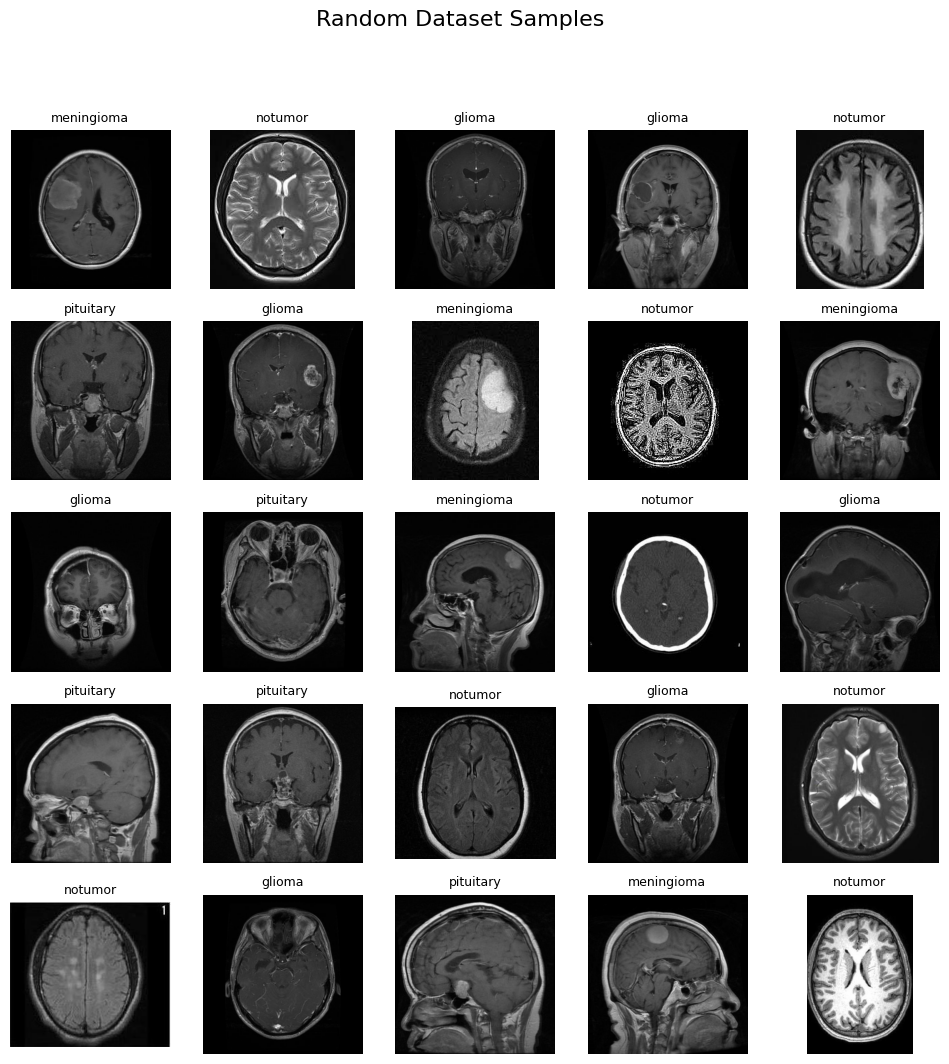

In [67]:
import random

base_path = r"D:\Brain Tumor project\dataset\Training"

# Class names
classes = ["glioma", "meningioma", "pituitary", "notumor"]

# Collect all images with labels
all_data = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)
    
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        all_data.append((img_path, class_name))  # (image, label)

# Pick 25 random samples from all dataset
sample_data = random.sample(all_data, 25)

# Plot images
plt.figure(figsize=(12,12))

for i, (img_path, label) in enumerate(sample_data):
    
    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot
    plt.subplot(5, 5, i+1)
    plt.imshow(img)
    
    # Show class name above image
    plt.title(label, fontsize=9)
    
    plt.axis('off')

plt.suptitle("Random Dataset Samples", fontsize=16)
plt.show()

In [2]:
base_path = r"D:\Brain Tumor project\dataset\Training"

# Define class names
classes = ["glioma", "meningioma", "pituitary", "notumor"]

data = []

# Loop through each class folder
for label, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)
    
    for img in tqdm(os.listdir(class_path)):
        img_path = os.path.join(class_path, img)
        
        # Store image path + label
        data.append([img_path, label])



100%|██████████| 1400/1400 [00:00<00:00, 350694.31it/s]


In [ ]:
# Create DataFrame
df = pd.DataFrame(data, columns=["image", "label"])

df.head()

,image,label
0,D:\Brain Tumor project\dataset\Training\glioma...,0
1,D:\Brain Tumor project\dataset\Training\glioma...,0
2,D:\Brain Tumor project\dataset\Training\glioma...,0
3,D:\Brain Tumor project\dataset\Training\glioma...,0
4,D:\Brain Tumor project\dataset\Training\glioma...,0


In [4]:
df.tail()

,image,label
5595,D:\Brain Tumor project\dataset\Training\notumo...,3
5596,D:\Brain Tumor project\dataset\Training\notumo...,3
5597,D:\Brain Tumor project\dataset\Training\notumo...,3
5598,D:\Brain Tumor project\dataset\Training\notumo...,3
5599,D:\Brain Tumor project\dataset\Training\notumo...,3


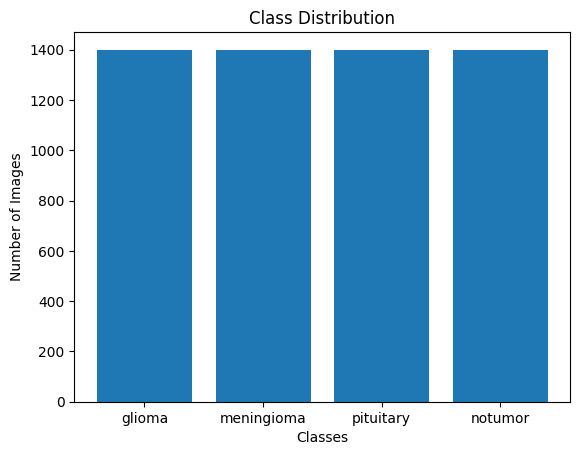

In [6]:
# Count samples per class
counts = df['label'].value_counts().sort_index()

# Class names (important for display)
class_names = ["glioma", "meningioma", "pituitary", "notumor"]

# Plot
plt.figure()
plt.bar(class_names, counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

## Dataset Balance

The dataset shows a relatively balanced distribution across the four classes 
(glioma, meningioma, pituitary, and no tumor).

In [7]:
# Image size
IMG_SIZE = 128

X = []
y = []

# Loop through dataset
for img_path, label in tqdm(df.values):
    
    # Read image
    img = cv2.imread(img_path)
    
    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Normalize (0 → 1)
    img = img / 255.0
    
    # Store
    X.append(img)
    y.append(label)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 5600/5600 [02:15<00:00, 41.48it/s]


X shape: (5600, 128, 128, 3)
y shape: (5600,)


## Data Augmentation

To improve the model's ability to generalize, we apply simple data augmentation techniques.

For each image, we generate additional variations such as:
- Horizontal flipping
- Slight rotation

This helps the model become more robust to changes in orientation and prevents overfitting, especially since image data can vary in real-world scenarios.

In [8]:
# Create new lists to store augmented data
X_aug = []
y_aug = []

# Loop through each image and its label
for img, label in tqdm(zip(X, y)):
    
    # 1. Keep original image
    X_aug.append(img)
    y_aug.append(label)
    
    # 2. Flip image horizontally (mirror image)
    flipped = cv2.flip(img, 1)
    X_aug.append(flipped)
    y_aug.append(label)
    
    # 3. Rotate image by 15 degrees
    h, w = img.shape[:2]  # get height and width
    
    # Create rotation matrix
    M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
    
    # Apply rotation
    rotated = cv2.warpAffine(img, M, (w, h))
    
    X_aug.append(rotated)
    y_aug.append(label)

# Convert lists to numpy arrays (required for ML models)
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# Print new dataset size
print("New shape:", X_aug.shape)

5600it [00:07, 709.89it/s] 


New shape: (16800, 128, 128, 3)


## Feature Extraction using CNN

Instead of feeding raw images directly into machine learning models, we use a pre-trained Convolutional Neural Network (CNN) as a feature extractor.

We remove the final classification layer and use the network to convert each image into a feature vector, which will be used as input for our ensemble models.

In [9]:
# Import MobileNetV2 model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2 without top layer (classification layer)
base_model = MobileNetV2(
    weights='imagenet',     # use pretrained weights
    include_top=False,
    input_shape=(128, 128, 3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [10]:
# Add Global Average Pooling to convert feature maps → vector
x = base_model.output
from tensorflow.keras.layers import GlobalAveragePooling2D
x = GlobalAveragePooling2D()(x)

# Final model (used only for feature extraction)
model = Model(inputs=base_model.input, outputs=x)

print("Model loaded successfully")

Model loaded successfully


In [11]:
# Extract features from augmented images
features = model.predict(X_aug, batch_size=32, verbose=1)

print("Feature shape:", features.shape)

525/525 ━━━━━━━━━━━━━━━━━━━━ 79s 142ms/step
Feature shape: (16800, 1280)


In [12]:
from sklearn.model_selection import train_test_split

# Split features and labels into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, y_aug, test_size=0.2, random_state=42, stratify=y_aug)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (13440, 1280)
X_test: (3360, 1280)


## Model Training

In this step, we train two ensemble models:
- Random Forest
- Gradient Boosting

These models are chosen to compare two different ensemble learning techniques: bagging and boosting.

## 1- Random Forest

In [13]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    random_state=42
)

# Train the model on training data
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# Make predictions on test data
rf_preds = rf_model.predict(X_test)


In [19]:
# Evaluate performance
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")


Random Forest Accuracy: 94.05%


## 2- Gradient Boosting

In [16]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,  # number of boosting stages
    learning_rate=0.1,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [17]:
# Predictions
gb_preds = gb_model.predict(X_test)


In [ ]:
# Evaluate
gb_acc = accuracy_score(y_test, gb_preds)

print(f"Gradient Boosting Accuracy: {gb_acc*100:.2f}%")

Gradient Boosting Accuracy: 91.64%


## Model Evaluation

To evaluate the performance of our models, we use multiple metrics including:
- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a deeper understanding of model performance beyond accuracy alone.

In [22]:
from sklearn.metrics import classification_report

# Random Forest report
print("Random Forest Report:\n")
print(classification_report(y_test, rf_preds))


Random Forest Report:

              precision    recall  f1-score   support

           0       0.98      0.90      0.94       840
           1       0.88      0.92      0.90       840
           2       0.93      0.98      0.96       840
           3       0.98      0.96      0.97       840

    accuracy                           0.94      3360
   macro avg       0.94      0.94      0.94      3360
weighted avg       0.94      0.94      0.94      3360



In [23]:
# Gradient Boosting report
print("\nGradient Boosting Report:\n")
print(classification_report(y_test, gb_preds))


Gradient Boosting Report:

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       840
           1       0.84      0.86      0.85       840
           2       0.93      0.97      0.95       840
           3       0.96      0.96      0.96       840

    accuracy                           0.92      3360
   macro avg       0.92      0.92      0.92      3360
weighted avg       0.92      0.92      0.92      3360



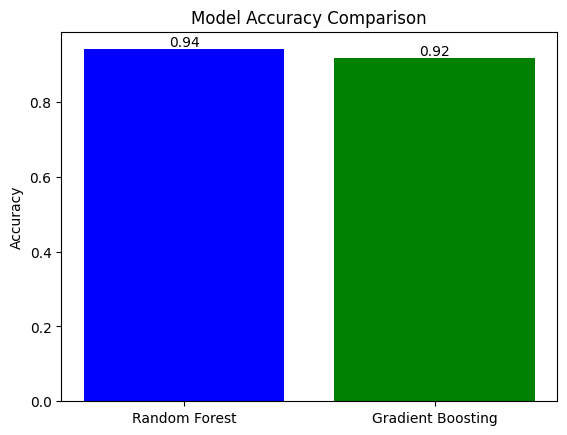

In [28]:
models = ["Random Forest", "Gradient Boosting"]
accuracies = [rf_acc, gb_acc]

plt.figure()

bars = plt.bar(models, accuracies, color=['blue', 'green'])

plt.bar_label(bars, fmt='%.2f')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics (macro for multi-class)
rf_precision = precision_score(y_test, rf_preds, average='macro')
rf_recall    = recall_score(y_test, rf_preds, average='macro')
rf_f1        = f1_score(y_test, rf_preds, average='macro')

gb_precision = precision_score(y_test, gb_preds, average='macro')
gb_recall    = recall_score(y_test, gb_preds, average='macro')
gb_f1        = f1_score(y_test, gb_preds, average='macro')

# Plot
labels = ["Precision", "Recall", "F1-score"]

rf_scores = [rf_precision, rf_recall, rf_f1]
gb_scores = [gb_precision, gb_recall, gb_f1]

x = np.arange(len(labels))



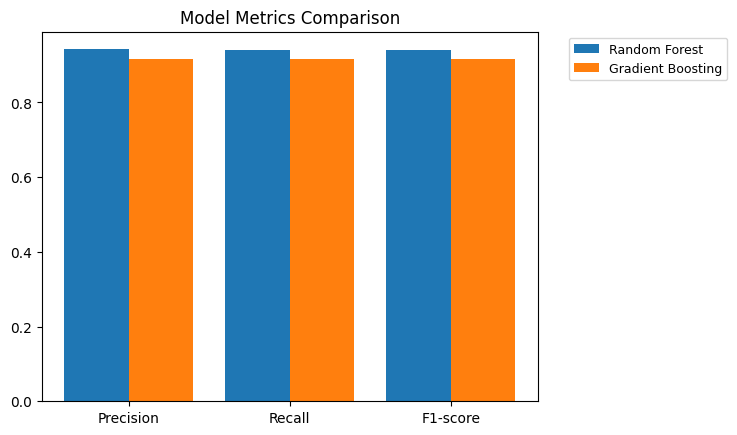

In [32]:
plt.figure()
plt.bar(x - 0.2, rf_scores, width=0.4, label='Random Forest')
plt.bar(x + 0.2, gb_scores, width=0.4, label='Gradient Boosting')

plt.xticks(x, labels)
plt.title("Model Metrics Comparison")
plt.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## <span style="color:red;">Results Analysis</span>

From the comparison chart, both models show very similar performance across all evaluation metrics (Precision, Recall, and F1-score).

However, Random Forest slightly outperforms Gradient Boosting in all metrics.

This indicates that Random Forest provides more stable and consistent performance on this dataset, while Gradient Boosting may require further tuning to reach optimal results.

Overall, <span style="color:green;">
Both models performed well, but Random Forest slightly outperformed Gradient Boosting.
</span>

The small performance gap suggests that both ensemble methods are effective, but Random Forest generalizes slightly better in this scenario.

## ------------------------------------------------------

## Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions across all classes.

It shows how many samples were correctly classified (diagonal values) and where the model made mistakes (off-diagonal values).

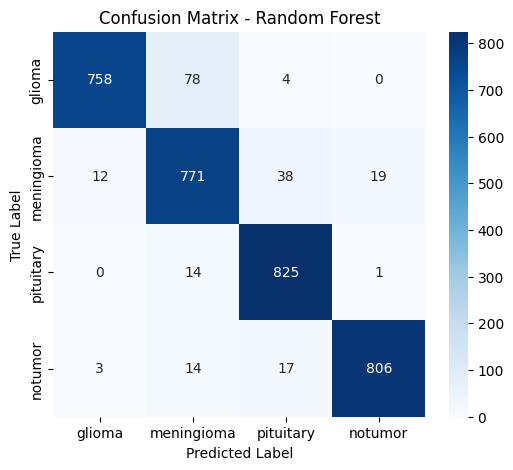

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = ["glioma", "meningioma", "pituitary", "notumor"]

# Compute confusion matrix using true labels and predictions
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,        
    fmt='d',           # integer format
    cmap='Blues',      
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**The confusion matrix shows that most predictions fall along the diagonal, indicating strong classification performance.

Some minor confusion exists between similar tumor types, which is expected due to visual similarities.**

## Image Prediction

This function takes any image and predicts its class using the trained model.

In [77]:
def predict_and_show(image_path):
    
    class_names = ["glioma", "meningioma", "pituitary", "notumor"]
    
    # 1. Read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Preprocess
    img_resized = cv2.resize(img, (128, 128)) / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)
    
    # 3. Feature extraction
    features = model.predict(img_resized)
    
    # 4. Prediction
    prediction = rf_model.predict(features)
    predicted_class = class_names[prediction[0]]
    
    # 5. Show image + prediction
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class}", color='blue')
    plt.axis('off')
    plt.show()
    
    return predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


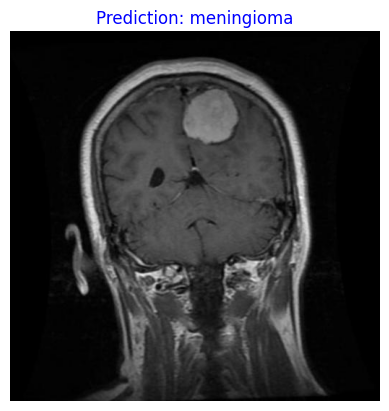

'meningioma'

In [78]:
predict_and_show(r"D:\Brain Tumor project\dataset\Training\meningioma\Tr-aug-me_19.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


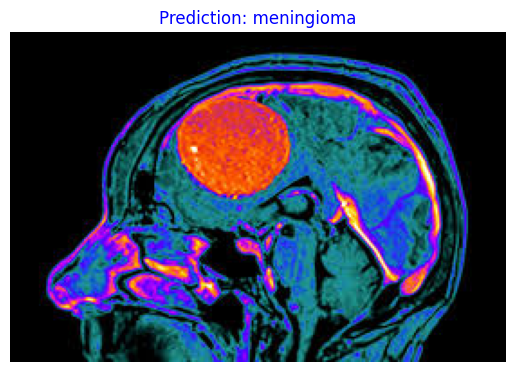

'meningioma'

In [81]:
predict_and_show(r"C:\Users\HP\Downloads\Meningioma_Brain_test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


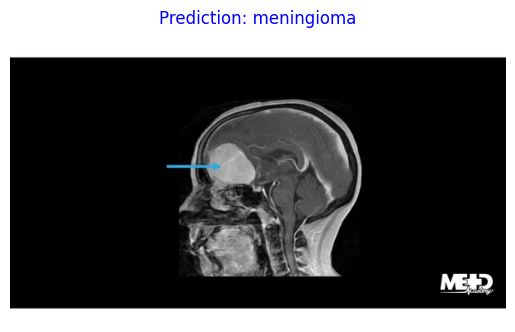

'meningioma'

In [79]:
predict_and_show(r"C:\Users\HP\Downloads\meningioma-frontal-lobe-test.webp")

## Saving Trained Models

Save the trained models and reuse them in the deployment phase.

In [82]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

# Save Gradient Boosting model
joblib.dump(gb_model, "gb_model.pkl")

print("Models saved successfully")

Models saved successfully


In [87]:
# Save CNN model
model.save_weights("cnn.weights.h5")
print("CNN saved successfully")

CNN saved successfully
